# 02 — Data Preprocessing & Pipeline Verification

**HemoVisionAI** — Acute Lymphoblastic Leukemia (ALL) Classification

This notebook demonstrates and verifies the stratified data pipeline.
All configuration is imported from `config.py`; all data-loading logic comes
from `preprocessing.data_pipeline`.

---

In [1]:
# ============================================================
# Cell 1: Imports and Project Setup
# ============================================================
import os
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# Add project root to sys.path so shared modules are importable.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Central configuration — single source of truth
from config import (
    DATASET_PATH, IMAGE_SIZE, BATCH_SIZE, SEED, VAL_SPLIT, NUM_CLASSES,
)

# Data pipeline — single implementation of all loading logic
from preprocessing.data_pipeline import (
    build_dataframe,
    stratified_split,
    print_split_summary,
    df_to_tf_dataset,
)

print(f"TensorFlow version: {tf.__version__}")
print(f"Project root:       {PROJECT_ROOT}")
print(f"Dataset path:       {DATASET_PATH}")
print(f"Image size:         {IMAGE_SIZE}")
print(f"Batch size:         {BATCH_SIZE}")

I0000 00:00:1785808013.056121   14454 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785808013.056516   14454 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785808013.097732   14454 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785808014.639269   14454 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow version: 2.21.0
Project root:       /home/chirag/ML_project1/HemoVisionAI
Dataset path:       /home/chirag/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1/Blood cell Cancer [ALL]
Image size:         (224, 224)
Batch size:         16


## 1. Build the Image DataFrame

Scan class directories → Pandas DataFrame with `image_path`, `label`, `class_name`.

In [2]:
# ============================================================
# Cell 2: Build DataFrame from Dataset Directory
# ============================================================
df, class_names = build_dataframe(DATASET_PATH)

print(f"\nLabel mapping:")
for idx, name in enumerate(class_names):
    print(f"  {idx} → {name}")

print(f"\nDataFrame shape: {df.shape}")
assert len(class_names) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, got {len(class_names)}"
df.head(10)

✅ Built DataFrame: 3242 images across 4 classes

Label mapping:
  0 → Benign
  1 → [Malignant] Pre-B
  2 → [Malignant] Pro-B
  3 → [Malignant] early Pre-B

DataFrame shape: (3242, 3)


,image_path,label,class_name
0,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
1,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
2,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
3,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
4,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
5,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
6,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
7,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
8,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign
9,/home/chirag/.cache/kagglehub/datasets/mohamma...,0,Benign


In [3]:
# ============================================================
# Cell 3: Overall Class Distribution
# ============================================================
print("Overall dataset class distribution:\n")
print(df["class_name"].value_counts().to_string())

Overall dataset class distribution:

class_name
[Malignant] early Pre-B    979
[Malignant] Pre-B          955
[Malignant] Pro-B          796
Benign                     512


## 2. Stratified Train / Validation Split

Using `sklearn.train_test_split(stratify=labels)` — guarantees proportional
class representation in both sets.

In [4]:
# ============================================================
# Cell 4: Stratified Split + Distribution Tables
# ============================================================
train_df, val_df = stratified_split(df, test_size=VAL_SPLIT, random_state=SEED)
print_split_summary(train_df, val_df, class_names)

# Verify all classes present
assert set(train_df["label"].unique()) == set(range(NUM_CLASSES))
assert set(val_df["label"].unique()) == set(range(NUM_CLASSES))
print("✅ All classes present in both splits — stratification confirmed!")

✅ Stratified split: 2593 train / 649 val

  TRAINING SET — Class Distribution
Class                             Count   Percentage
----------------------------------------------------
Benign                              409      15.77 %
[Malignant] Pre-B                   764      29.46 %
[Malignant] Pro-B                   637      24.57 %
[Malignant] early Pre-B             783      30.20 %
----------------------------------------------------
TOTAL                              2593     100.00 %

  VALIDATION SET — Class Distribution
Class                             Count   Percentage
----------------------------------------------------
Benign                              103      15.87 %
[Malignant] Pre-B                   191      29.43 %
[Malignant] Pro-B                   159      24.50 %
[Malignant] early Pre-B             196      30.20 %
----------------------------------------------------
TOTAL                               649     100.00 %

✅ All classes present in both spli

## 3. Build `tf.data.Dataset` Pipelines

Pipeline: load → decode → resize → cast float32 → batch → prefetch.
Pixel values stay in `[0, 255]`; the model normalises internally via `Rescaling(1/255)`.

In [5]:
# ============================================================
# Cell 5: Create tf.data.Datasets
# ============================================================
train_ds = df_to_tf_dataset(train_df, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = df_to_tf_dataset(val_df,   image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches:   {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

Training batches:   163
Validation batches: 41


E0000 00:00:1785808035.681400   14454 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
# ============================================================
# Cell 6: Verify Batch Shapes and Pixel Range
# ============================================================
for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    print(f"Pixel min:  {tf.reduce_min(images).numpy():.2f}")
    print(f"Pixel max:  {tf.reduce_max(images).numpy():.2f}")
    print(f"Dtype:      {images.dtype}")

    assert images.shape[1:] == (*IMAGE_SIZE, 3), f"Wrong shape: {images.shape}"
    assert images.dtype == tf.float32
    assert tf.reduce_max(images).numpy() > 1.0, (
        "ERROR: Pixels ≤ 1.0 — pipeline is normalising. "
        "Model has Rescaling(1/255) internally; pipeline must deliver [0, 255]."
    )

print("\n✅ Pipeline verified!")

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Pixel min:  0.00
Pixel max:  255.00
Dtype:      <dtype: 'float32'>

✅ Pipeline verified!


## 4. Visualise Training Samples

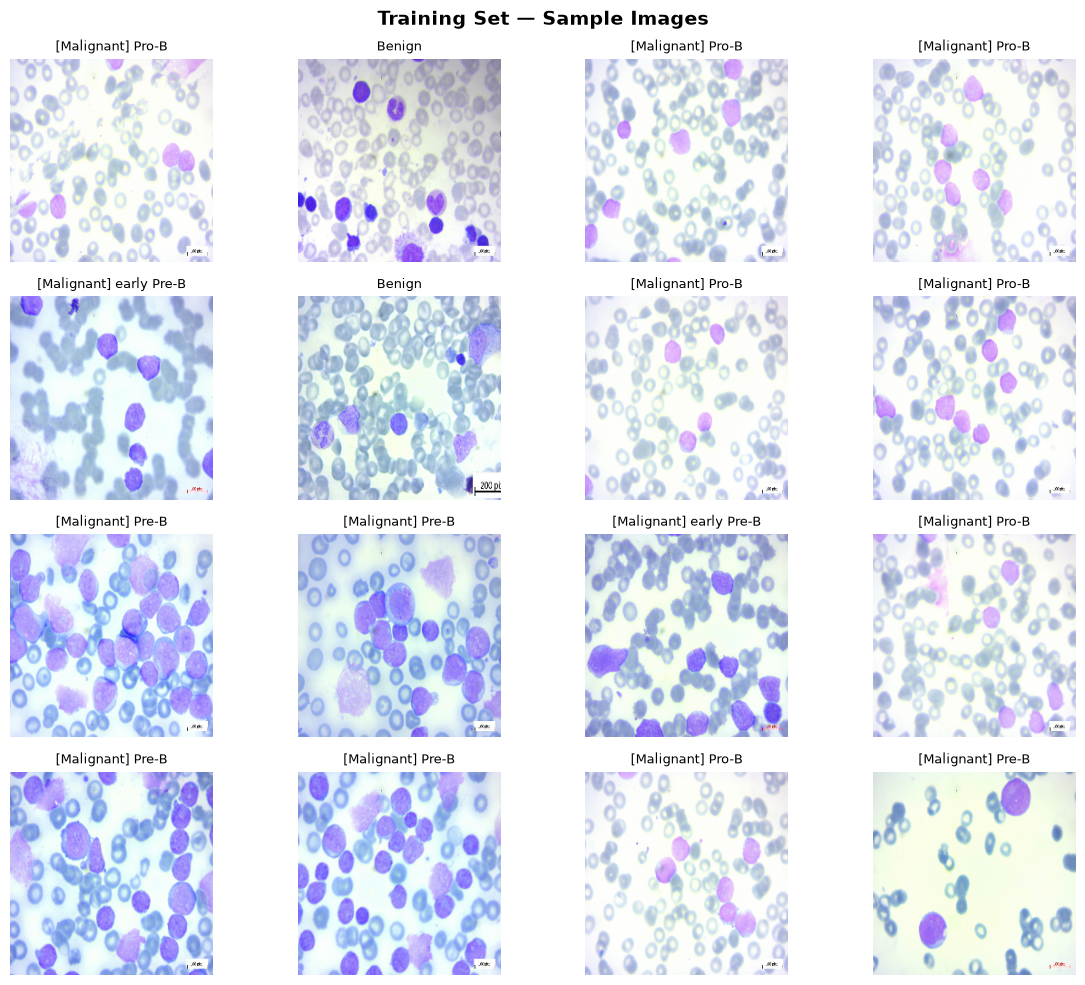

In [7]:
# ============================================================
# Cell 7: Display Sample Training Images
# ============================================================
plt.figure(figsize=(12, 10))
for images, labels in train_ds.take(1):
    for i in range(min(16, images.shape[0])):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        plt.title(class_names[labels[i].numpy()], fontsize=9)
        plt.axis("off")
plt.suptitle("Training Set — Sample Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Data Augmentation Preview

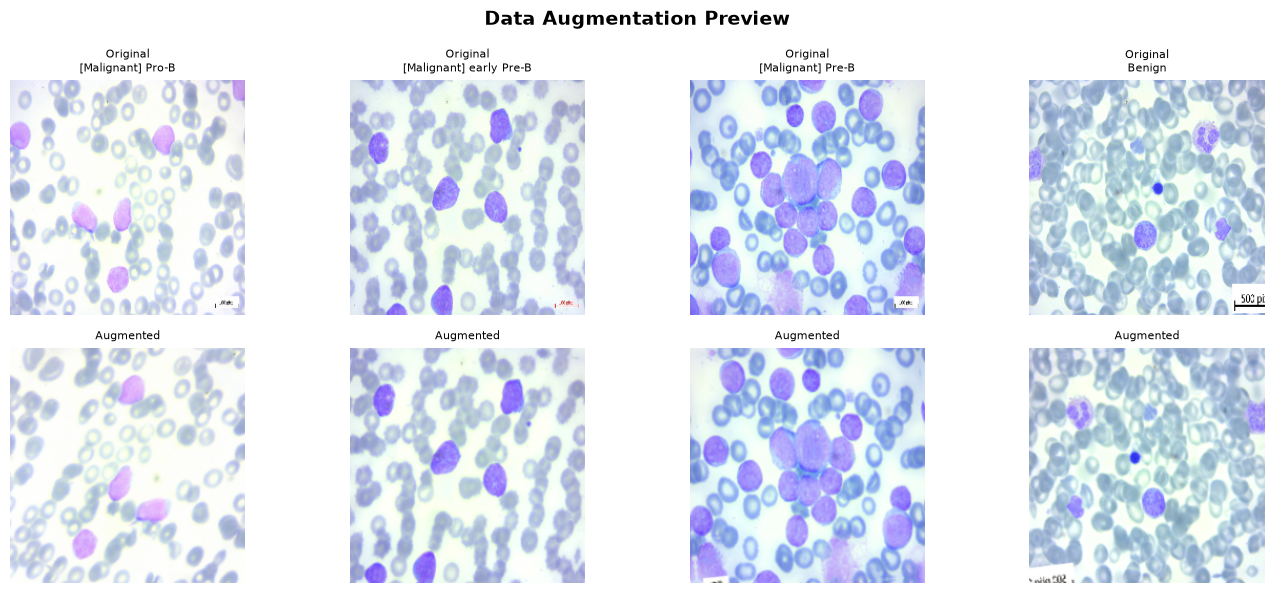

In [8]:
# ============================================================
# Cell 8: Augmentation Preview
# ============================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="DataAugmentation")

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(4):
        original = images[i]
        augmented = data_augmentation(tf.expand_dims(original, 0), training=True)[0]
        plt.subplot(2, 4, i + 1)
        plt.imshow(tf.cast(original, tf.uint8).numpy())
        plt.title(f"Original\n{class_names[labels[i].numpy()]}", fontsize=8)
        plt.axis("off")
        plt.subplot(2, 4, i + 5)
        plt.imshow(tf.cast(tf.clip_by_value(augmented, 0, 255), tf.uint8).numpy())
        plt.title("Augmented", fontsize=8)
        plt.axis("off")
plt.suptitle("Data Augmentation Preview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

✅ Data pipeline verified:
- DataFrame built from disk (3 242 images, 4 classes)
- Stratified 80/20 split with all classes in both sets
- `tf.data.Dataset` delivers `float32 [0, 255]` batches
- Model will normalise internally via `Rescaling(1/255)`